In [4]:
import numpy as np
import xarray as xr

import warnings
warnings.filterwarnings('ignore')

In [6]:
ds = xr.open_dataset('/home/z2034747/Research/Datasets/P_Per/pper_hail_1979_2023.nc')
ds_hail = ds['p_perfect_hail']

In [9]:
# Entire Dataset:

mean = ds_hail.mean(dim= 'time')
std = ds_hail.std(dim= 'time')
counts = len(ds_hail.time)

threshold= 15
arr_15 = ds_hail.where(ds_hail >= threshold) * 0 + 1
sum_15 = arr_15.sum(axis= 0)
freq_15 = sum_15 / counts * 100

threshold= 5
arr_5 = ds_hail.where(ds_hail >= threshold) * 0 + 1
sum_5 = arr_5.sum(axis= 0)
freq_5 = sum_5 / counts * 100


In [15]:
entire_climatology = xr.Dataset(data_vars= {'mean': mean, 'std': std, 'freq_15': freq_15, 'freq_5': freq_5},
                                coords= {'time': ds.time, 'x': ds.x, 'y': ds.y},
                                attrs= ds.attrs
                                )

In [17]:
entire_climatology.to_netcdf('/home/scratch/peldridge/pper_climo/pper_hail_climatology.nc')

In [20]:
era = xr.open_dataset('/home/scratch/era5/era5_sigma/era5_1979-01-01.nc')

In [21]:
era

<xarray.Dataset> Size: 3GB
Dimensions:    (longitude: 245, latitude: 150, level: 93, time: 24)
Coordinates:
  * longitude  (longitude) float32 980B 234.0 234.2 234.5 ... 294.5 294.8 295.0
  * latitude   (latitude) float32 600B 55.0 54.75 54.5 ... 18.25 18.0 17.75
  * level      (level) float64 744B 45.0 46.0 47.0 48.0 ... 135.0 136.0 137.0
  * time       (time) datetime64[ns] 192B 1979-01-01 ... 1979-01-01T23:00:00
Data variables:
    t          (time, level, latitude, longitude) float64 656MB ...
    q          (time, level, latitude, longitude) float64 656MB ...
    u          (time, level, latitude, longitude) float64 656MB ...
    v          (time, level, latitude, longitude) float64 656MB ...
    z          (time, level, latitude, longitude) float32 328MB ...
    p          (time, level, latitude, longitude) float32 328MB ...
Attributes:
    CDI:          Climate Data Interface version ?? (http://mpimet.mpg.de/cdi)
    Conventions:  CF-1.6
    history:      Mon Apr 08 18:22:19 2019: cdo splitday 1979-01_1.nc /mnt/dy...
    CDO:          Climate Data Operators version 1.7.0 (http://mpimet.mpg.de/...

In [22]:
ds_sel = era.isel(time= 0)

In [23]:
ds_sel

<xarray.Dataset> Size: 137MB
Dimensions:    (longitude: 245, latitude: 150, level: 93)
Coordinates:
  * longitude  (longitude) float32 980B 234.0 234.2 234.5 ... 294.5 294.8 295.0
  * latitude   (latitude) float32 600B 55.0 54.75 54.5 ... 18.25 18.0 17.75
  * level      (level) float64 744B 45.0 46.0 47.0 48.0 ... 135.0 136.0 137.0
    time       datetime64[ns] 8B 1979-01-01
Data variables:
    t          (level, latitude, longitude) float64 27MB ...
    q          (level, latitude, longitude) float64 27MB ...
    u          (level, latitude, longitude) float64 27MB ...
    v          (level, latitude, longitude) float64 27MB ...
    z          (level, latitude, longitude) float32 14MB ...
    p          (level, latitude, longitude) float32 14MB ...
Attributes:
    CDI:          Climate Data Interface version ?? (http://mpimet.mpg.de/cdi)
    Conventions:  CF-1.6
    history:      Mon Apr 08 18:22:19 2019: cdo splitday 1979-01_1.nc /mnt/dy...
    CDO:          Climate Data Operators version 1.7.0 (http://mpimet.mpg.de/...

In [47]:
era5_sel = era.isel(level= 0)

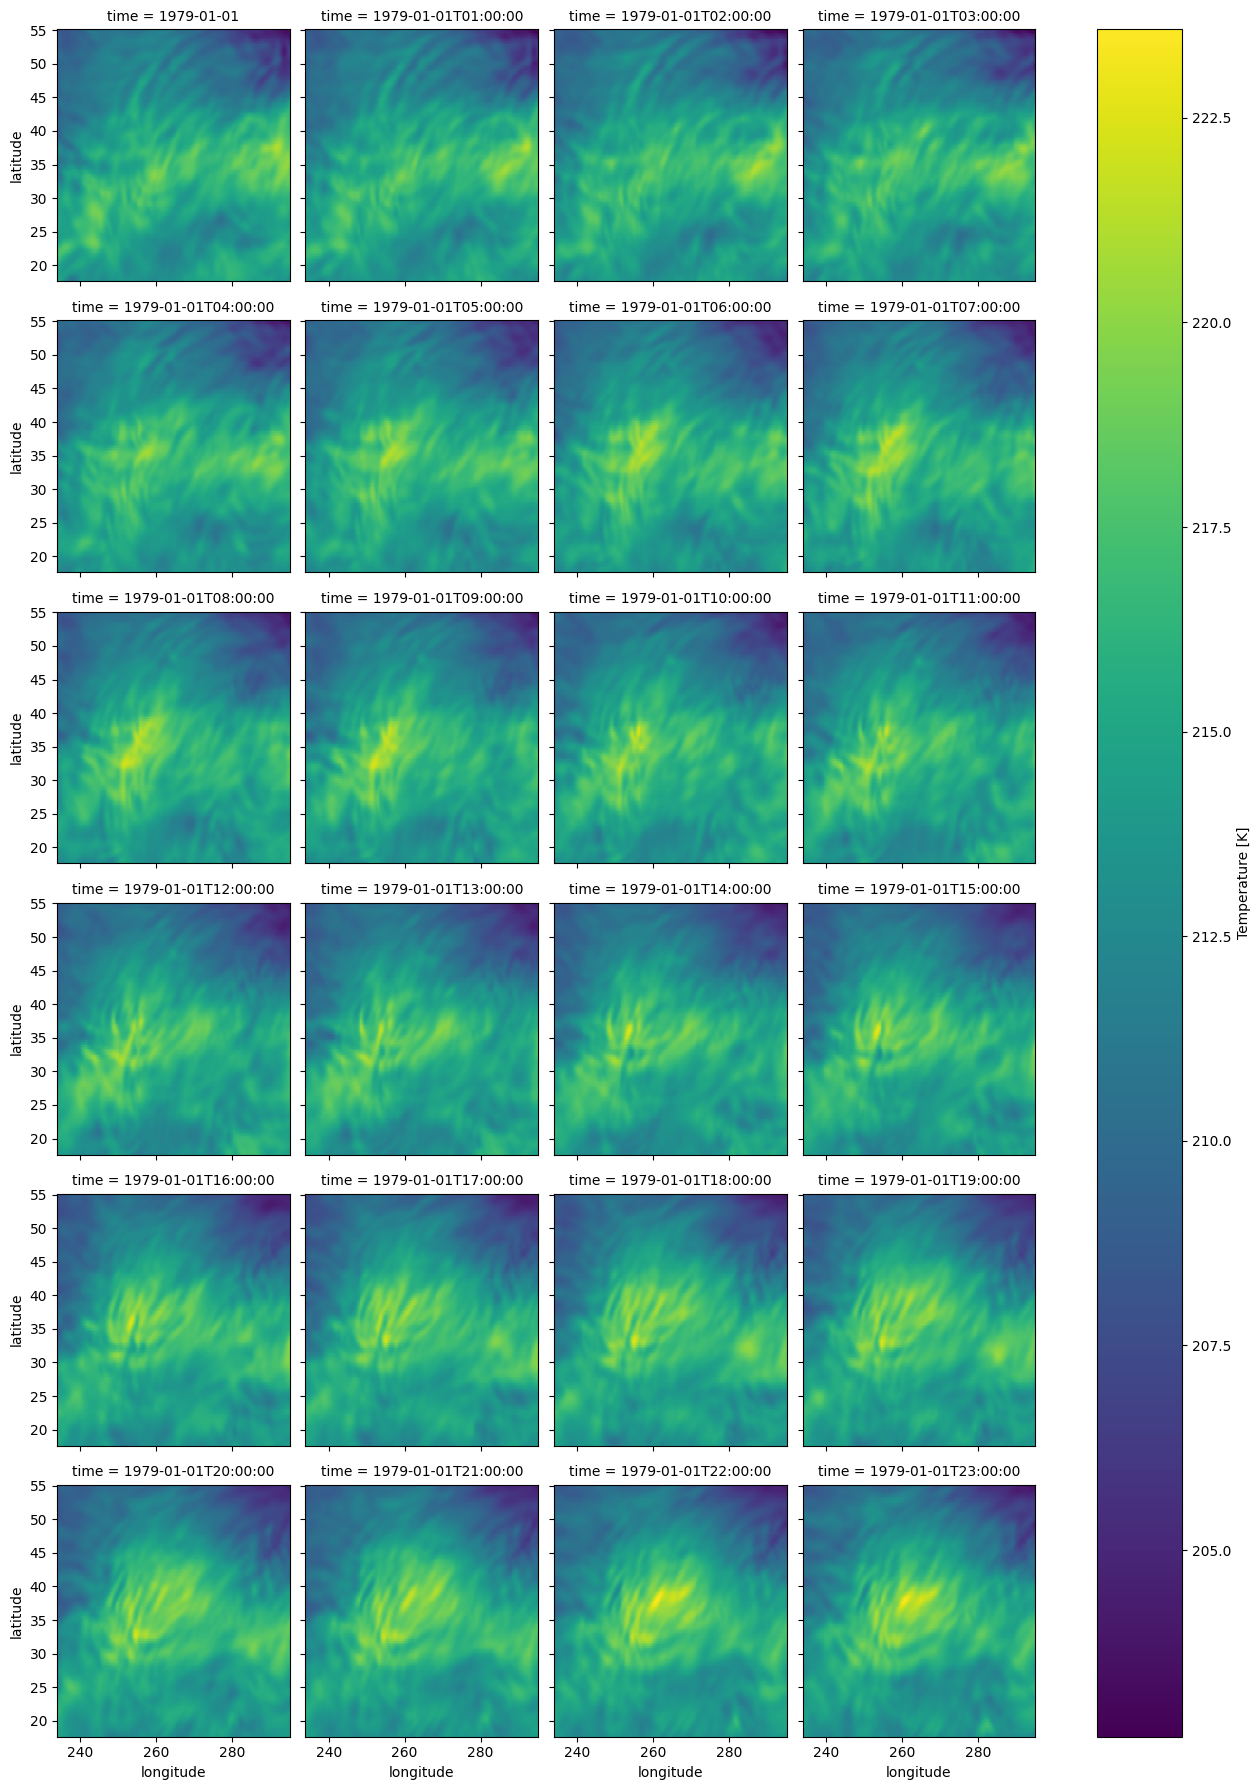

In [48]:
import matplotlib.pyplot as plt
era5_sel.t.plot.pcolormesh(col= 'time', col_wrap= 4)

In [49]:
era5_sel = era.isel(time= 0, level= 0)

In [50]:
era5_sel['z'] = era5_sel['z'] / 9.81

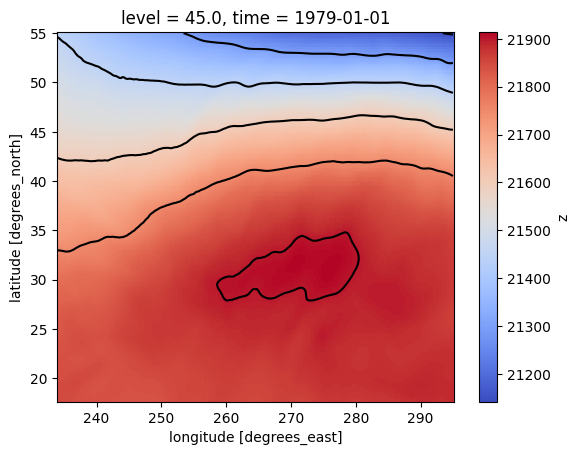

In [51]:
era5_sel.z.plot(cmap= 'coolwarm')
era5_sel.z.plot.contour(colors= 'k')

In [37]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

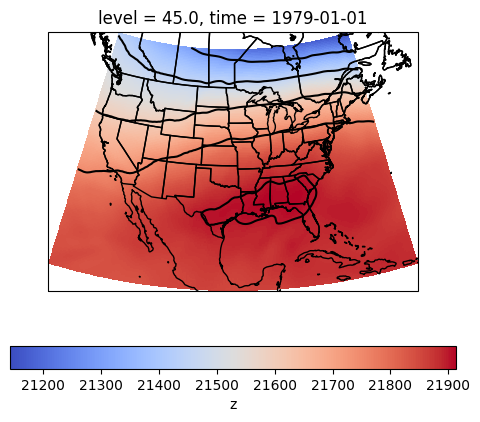

In [62]:
ax = plt.subplot(1, 1, 1, projection = ccrs.AlbersEqualArea(central_longitude= (era.longitude.max().values + era.longitude.min().values) / 2))
era5_sel.z.plot(ax= ax, cmap= 'coolwarm', cbar_kwargs= {'orientation': 'horizontal', 'shrink': 0.9}, transform= ccrs.PlateCarree())
era5_sel.z.plot.contour(ax= ax, colors= 'k', transform= ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.STATES)

In [61]:
era.longitude.max().values

array(295.)